In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format='svg'
#%config InlineBackend.figure_format='retina'

import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

from geneinfo.genelist import GeneListCollection
from geneinfo.genelist import GeneList as glist
from geneinfo.plot import ChromIdeogram

# if any(x in os.environ for x in ["VSCODE_PID", "VSCODE_CWD", "JPY_PARENT_PID"]):
#     plt.rcParams['figure.facecolor'], plt.rcParams['axes.facecolor'] = '#1F1F1F', '#1F1F1F'

sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')


In [2]:
df = pd.read_csv('../data/adc9507_Data_S1.csv',
                 names=['chrom', 'start', 'end', 'linar_id', 'nearest_neighbor_gene', 
                        'lncRNA_id', 'cCREs_id', 'gene_name', 'lineage_name', 'phylop_score',
                          'p_value', 'q_value']
).loc[lambda df: (df.gene_name != 'NONE') & (df.chrom == 'chrX')]
df['log_q_value'] = -np.log10(df.q_value)
df.head(1000)

/Users/kmt/primate-accel-reg/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,chrom,start,end,linar_id,nearest_neighbor_gene,lncRNA_id,cCREs_id,gene_name,lineage_name,phylop_score,p_value,q_value,log_q_value
79405,chrX,138710262,138711758,HLinAR-Rank56*,ENSG00000129682,URS00005066C4_9606,EH38E2771120,FGF13,Human,24.96205,0.0,0.0,inf
79406,chrX,103910029,103910206,HLinAR-Rank87,ENSG00000158427,URS0001A190A0_9606,NONE,TMSB15B,Human,19.65286,0.0,0.0,inf
79407,chrX,71910623,71911026,HLinAR-Rank157,ENSG00000204131,URS0001BF082B_9606,EH38E2758254,NHSL2,Human,15.93686,0.0,0.0,inf
79408,chrX,139142129,139142405,HLinAR-Rank220,ENSG00000129682,URS00009B02DD_9606,NONE,FGF13,Human,14.27478,0.0,0.0,inf
79409,chrX,116107686,116108025,HLinAR-Rank234,ENSG00000180772,NONE,NONE,AGTR2,Human,13.91546,0.0,0.0,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80745,chrX,3346694,3346782,Rank543,ENSG00000101825,NONE,EH38E2739917,MXRA5,Macaca silenus,11.06772,0.0,0.0,inf
80746,chrX,17099731,17099796,Rank548,ENSG00000169891,URS0000EA83EA_9606,NONE,REPS2,Macaca silenus,11.00654,0.0,0.0,inf
80747,chrX,71315115,71315207,Rank550,ENSG00000147166,URS00008BD647_9606,NONE,ITGB1BP2,Macaca silenus,10.95628,0.0,0.0,inf
80748,chrX,38158135,38158170,Rank559,ENSG00000101955,URS00008C0DEE_9606,NONE,SRPX,Macaca silenus,10.79256,0.0,0.0,inf


In [3]:
#df = df.sort_values('q_value').iloc[:100]

In [4]:
genes_df = pd.DataFrame(dict(gene=np.sort(df.gene_name.unique())))
genes_df.head()

,gene
0,06/Sep
1,ABCB7
2,ABCD1
3,AC097625.2
4,AC236972.4


# ???

In [5]:
genes_df = genes_df.loc[['/' not in x for x in genes_df.gene]].reset_index()
genes_df['block'] = genes_df.index // (1 + genes_df.index.size // 9)
genes_df = genes_df.set_index('gene')

In [6]:
df = df.loc[df.gene_name.isin(genes_df.index)]

In [7]:
nDEG_genes = pd.read_csv('../data/nDEG_Table_S5.csv')
cDEG_genes = pd.read_csv('../data/cDEG_Table_S6.csv')
cDEG_genes

,gene,FDR,coef,diff_exp,chromosome
0,AKAP4,2.000000e-05,1.928847,X,X
1,BRWD3,6.244907e-03,1.745363,X,X
2,CFAP47,2.590000e-05,2.254271,X,X
3,DDX3X,2.000000e-05,1.536328,X,X
4,DIAPH2,4.010000e-07,2.875843,X,X
5,DYNLT3,1.156475e-03,1.779049,X,X
6,EDA,2.590000e-05,1.094076,X,X
7,FHL1,2.714712e-03,1.619648,X,X
8,FTSJ1,8.355442e-04,1.830052,X,X
9,HDX,2.906312e-03,1.644120,X,X


In [8]:
all_lin_names = np.sort(df.lineage_name.unique())
ext_lin_names = np.sort(all_lin_names[[len(x.split()) == 2 or x == 'Human' for x in all_lin_names]])
glist(sorted(ext_lin_names))

Aotus nancymaae,Lemur catta,Papio hamadryas
Ateles geoffroyi,Lophocebus aterrimus,Piliocolobus tephrosceles
Callithrix jacchus,Loris tardigradus,Pithecia pithecia
Cebus albifrons,Macaca assamensis,Pongo abelii
Cercocebus atys,Macaca mulatta,Pongo pygmaeus
Cercopithecus albogularis,Macaca nemestrina,Prolemur simus
Cercopithecus mona,Macaca silenus,Pygathrix nigripes
Chlorocebus aethiops,Mandrillus leucophaeus,Rhinopithecus roxellana
Chlorocebus sabaeus,Mandrillus sphinx,Rhinopithecus strykeri
Colobus angolensis,Microcebus murinus,Saguinus midas
Colobus guereza,Nomascus siki,Sapajus apella


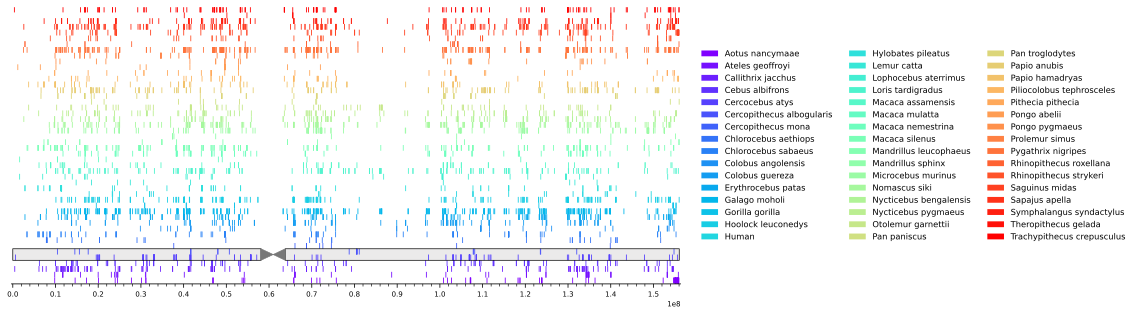

In [9]:
from matplotlib.pyplot import cm
import numpy as np

species = ext_lin_names # ['Human', 'Gorilla gorilla', 'Pan troglodytes']

color = cm.rainbow(np.linspace(0, 1, len(species)))

g = ChromIdeogram(chrom='chrX', assembly='hg38', axes_height_inches=5, ylim=(0, len(species))) 
g.draw_chromosomes()
base = 0
for species_name, color in zip(species, color):
    segments = list(df.loc[df.lineage_name == species_name, ['chrom', 'start', 'end']].itertuples(index=False))
    g.add_segments(segments, facecolor=color, label=species_name, height=1, base=base)
    base += 1
g.add_legend(fontsize='small', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, ncol=3)




In [10]:
df.head()

,chrom,start,end,linar_id,nearest_neighbor_gene,lncRNA_id,cCREs_id,gene_name,lineage_name,phylop_score,p_value,q_value,log_q_value
79405,chrX,138710262,138711758,HLinAR-Rank56*,ENSG00000129682,URS00005066C4_9606,EH38E2771120,FGF13,Human,24.96205,0.0,0.0,inf
79406,chrX,103910029,103910206,HLinAR-Rank87,ENSG00000158427,URS0001A190A0_9606,NONE,TMSB15B,Human,19.65286,0.0,0.0,inf
79407,chrX,71910623,71911026,HLinAR-Rank157,ENSG00000204131,URS0001BF082B_9606,EH38E2758254,NHSL2,Human,15.93686,0.0,0.0,inf
79408,chrX,139142129,139142405,HLinAR-Rank220,ENSG00000129682,URS00009B02DD_9606,NONE,FGF13,Human,14.27478,0.0,0.0,inf
79409,chrX,116107686,116108025,HLinAR-Rank234,ENSG00000180772,NONE,NONE,AGTR2,Human,13.91546,0.0,0.0,inf


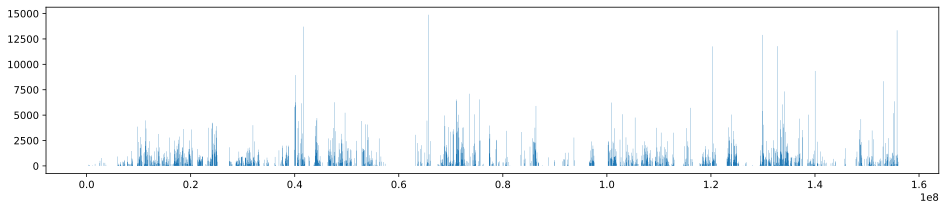

In [13]:
from chrom_windows import window

@window(50_000)
def tot_har_length(df):
    return sum(df.har_end - df.har_start)

def stairs(df, start='start', end='end', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

_df = (df
       .assign(har_start=df.start)
       .assign(har_end=df.end)
       .sort_values(['chrom', 'har_start', 'har_end'])
       .groupby('chrom').apply(tot_har_length)
       .reset_index(level=1, drop=True)
       .reset_index()
)
plt.figure(figsize=(16, 3))
plt.fill_between(_df.start, 0, _df.tot_har_length, step='post', ec='none')


# _df
# plot_df = stairs(_df)
# plot_df
# plt.fill_between(plot_df.pos, 0, plot_df.tot_har_length)
# plt.xlabel('Genomic position (chrX)')


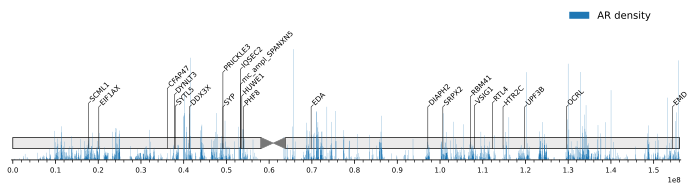

In [20]:

from geneinfo.genelist import GeneList as glist
from geneinfo.plot import ChromIdeogram
from geneinfo.coords import gene_labels
from matplotlib.axes import Axes

g = ChromIdeogram('chrX', assembly='hg38', 
                    font_size=5,
                    ylim=(0, 10),
                    #    zoom_height_ratio=2, 
#                        zoom_font_size=5, 
#                        zoom_effect_alpha=0.2,
# #                       
#                           zooms=[
#         (15_000_000, 23_000_000),
#         (33_000_000, 59_000_000),
#         (95_000_000, 133_000_000),
#     ]
                      )

g.draw_chromosomes(base=1, height=1)
_df['y']= _df.tot_har_length
_df['x']= _df.start
g.map_method(Axes.fill_between, data=_df, 
             x='x', y='y', yaxis=(0, 10), step='post', ec='none', label='AR density',
             fc='tab:blue')
coords = gene_labels(sheet.get('cDEG'), assembly='hg38')
g.add_labels(coords, base=g.ideogram_base, min_height=g.ideogram_height*4, 
             zoom_base=g.ideogram_base, zoom_min_height=g.ideogram_height*3, color='black')
g.add_legend(loc='center left', bbox_to_anchor=(0.82, 1.3), fontsize="10", frameon=False)

<Axes: ylabel='lineage_name'>

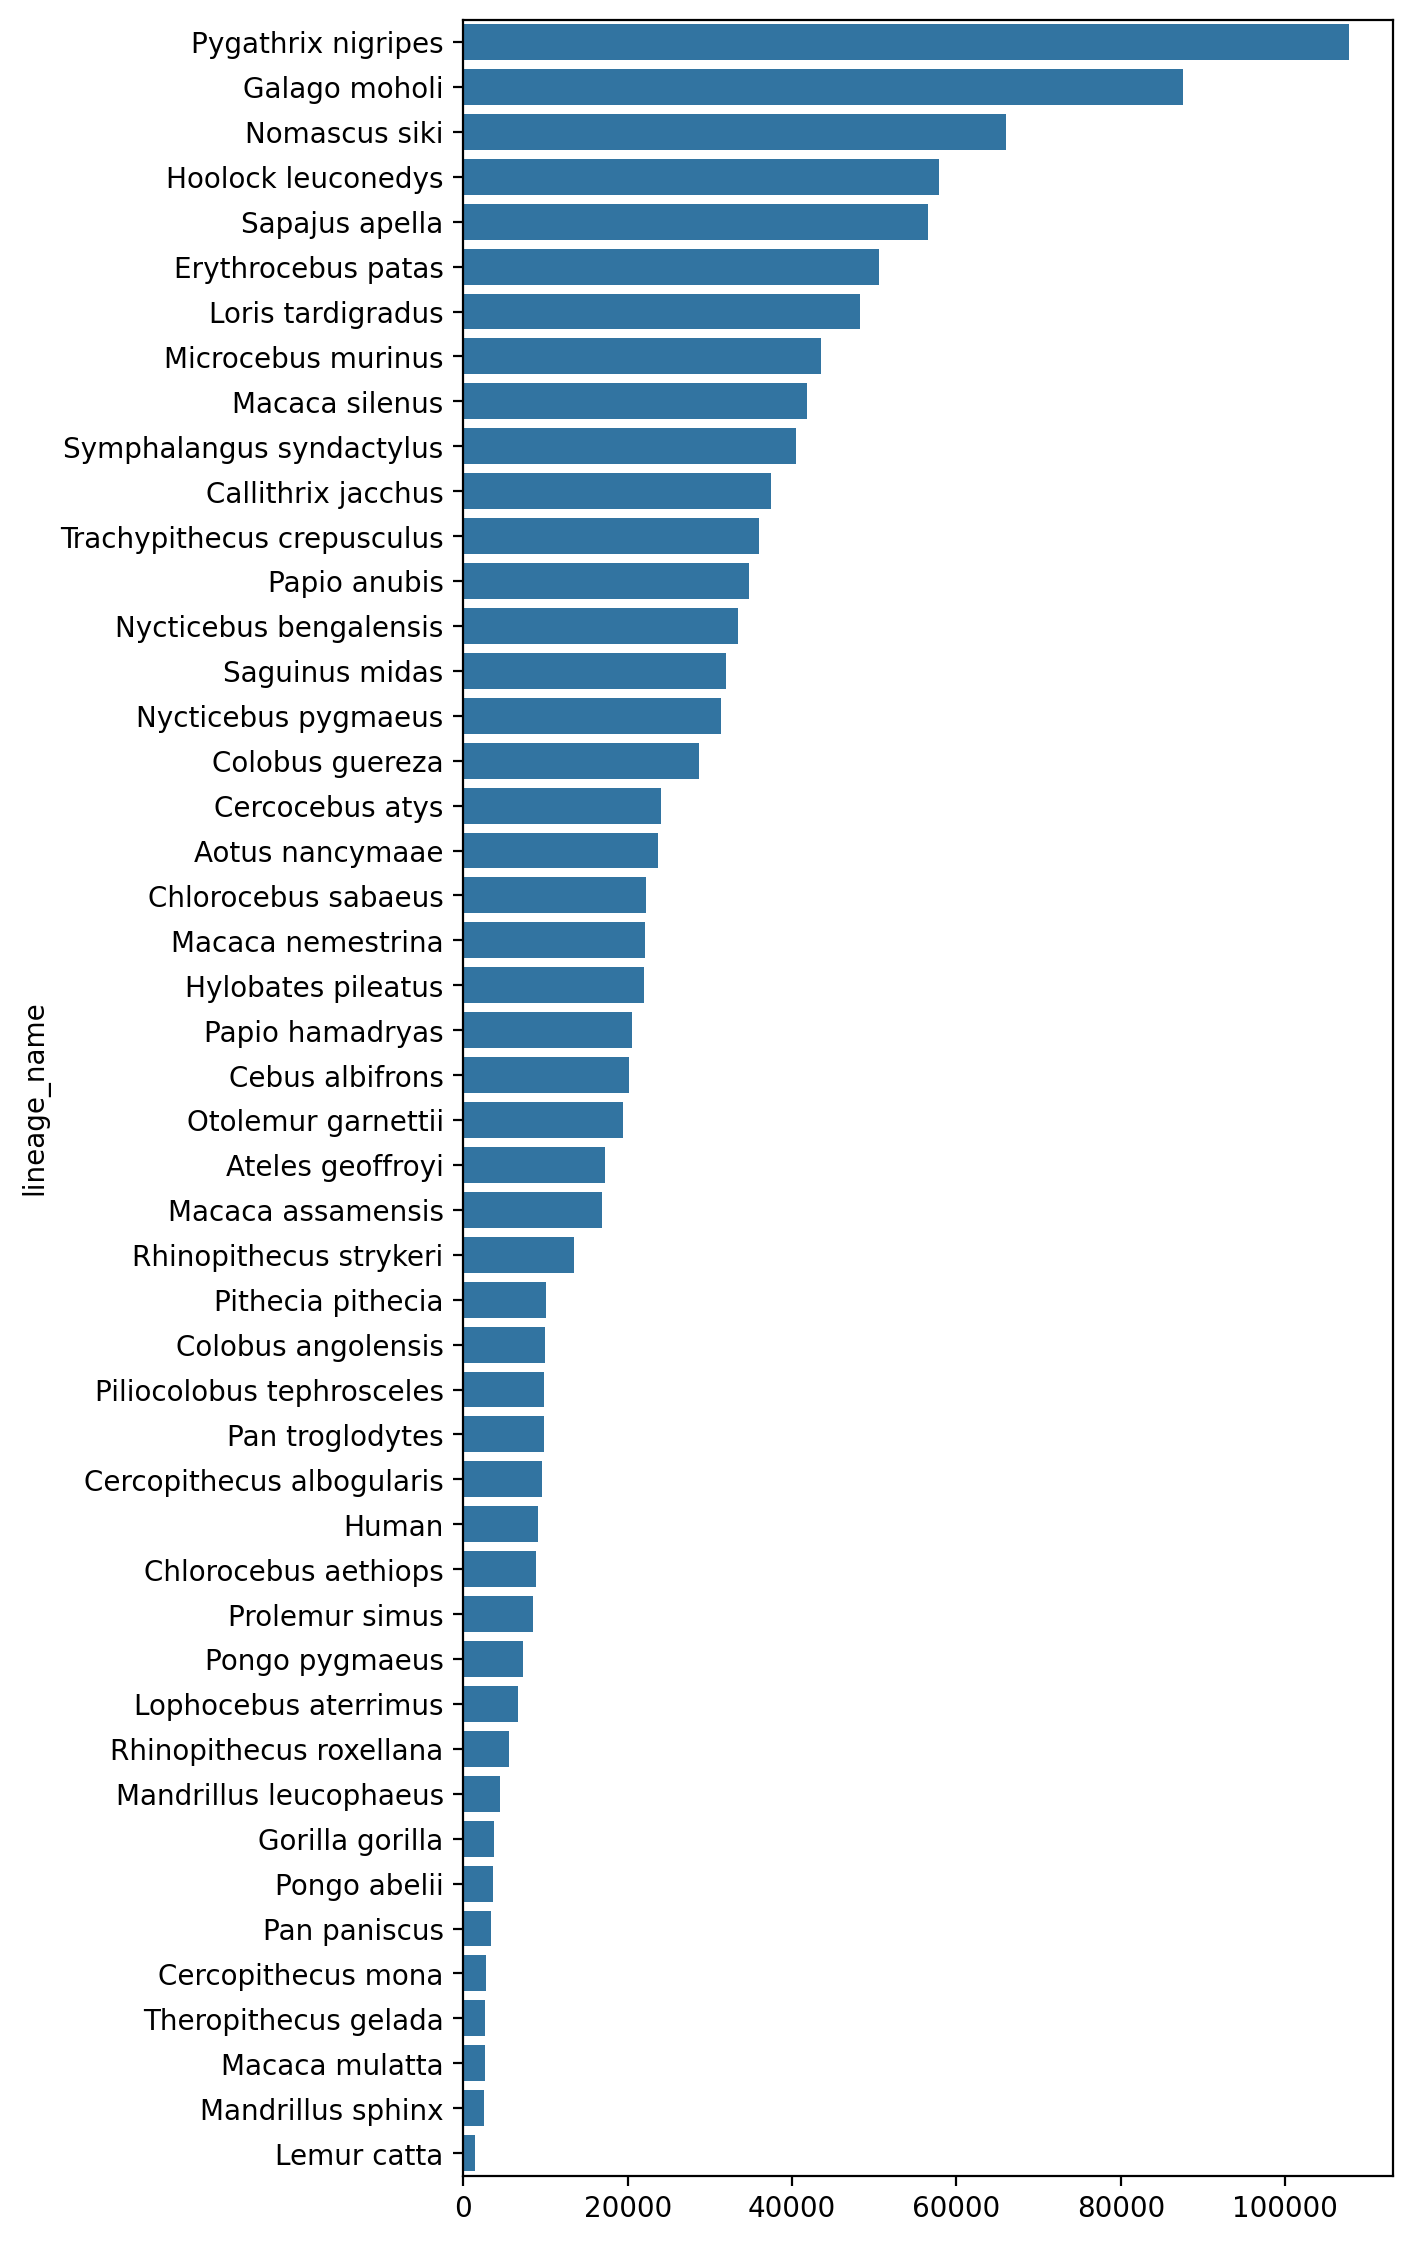

In [58]:
plt.figure(figsize=(6, 14))
_df = df.loc[df.lineage_name.isin(ext_lin_names)].groupby('lineage_name').apply(lambda df: sum(df.end - df.start)).sort_values(ascending=False)
sns.barplot(x=_df.values, y=_df.index)

In [114]:
def barplot_facet_with_hue(*args, **kwargs):
    x, y, hue, *_ = args
    df = kwargs.pop('data')
    sns.barplot(df, x=x, y=y, hue=df[hue], order=sorted(df.gene_name.unique()), palette='Set2')

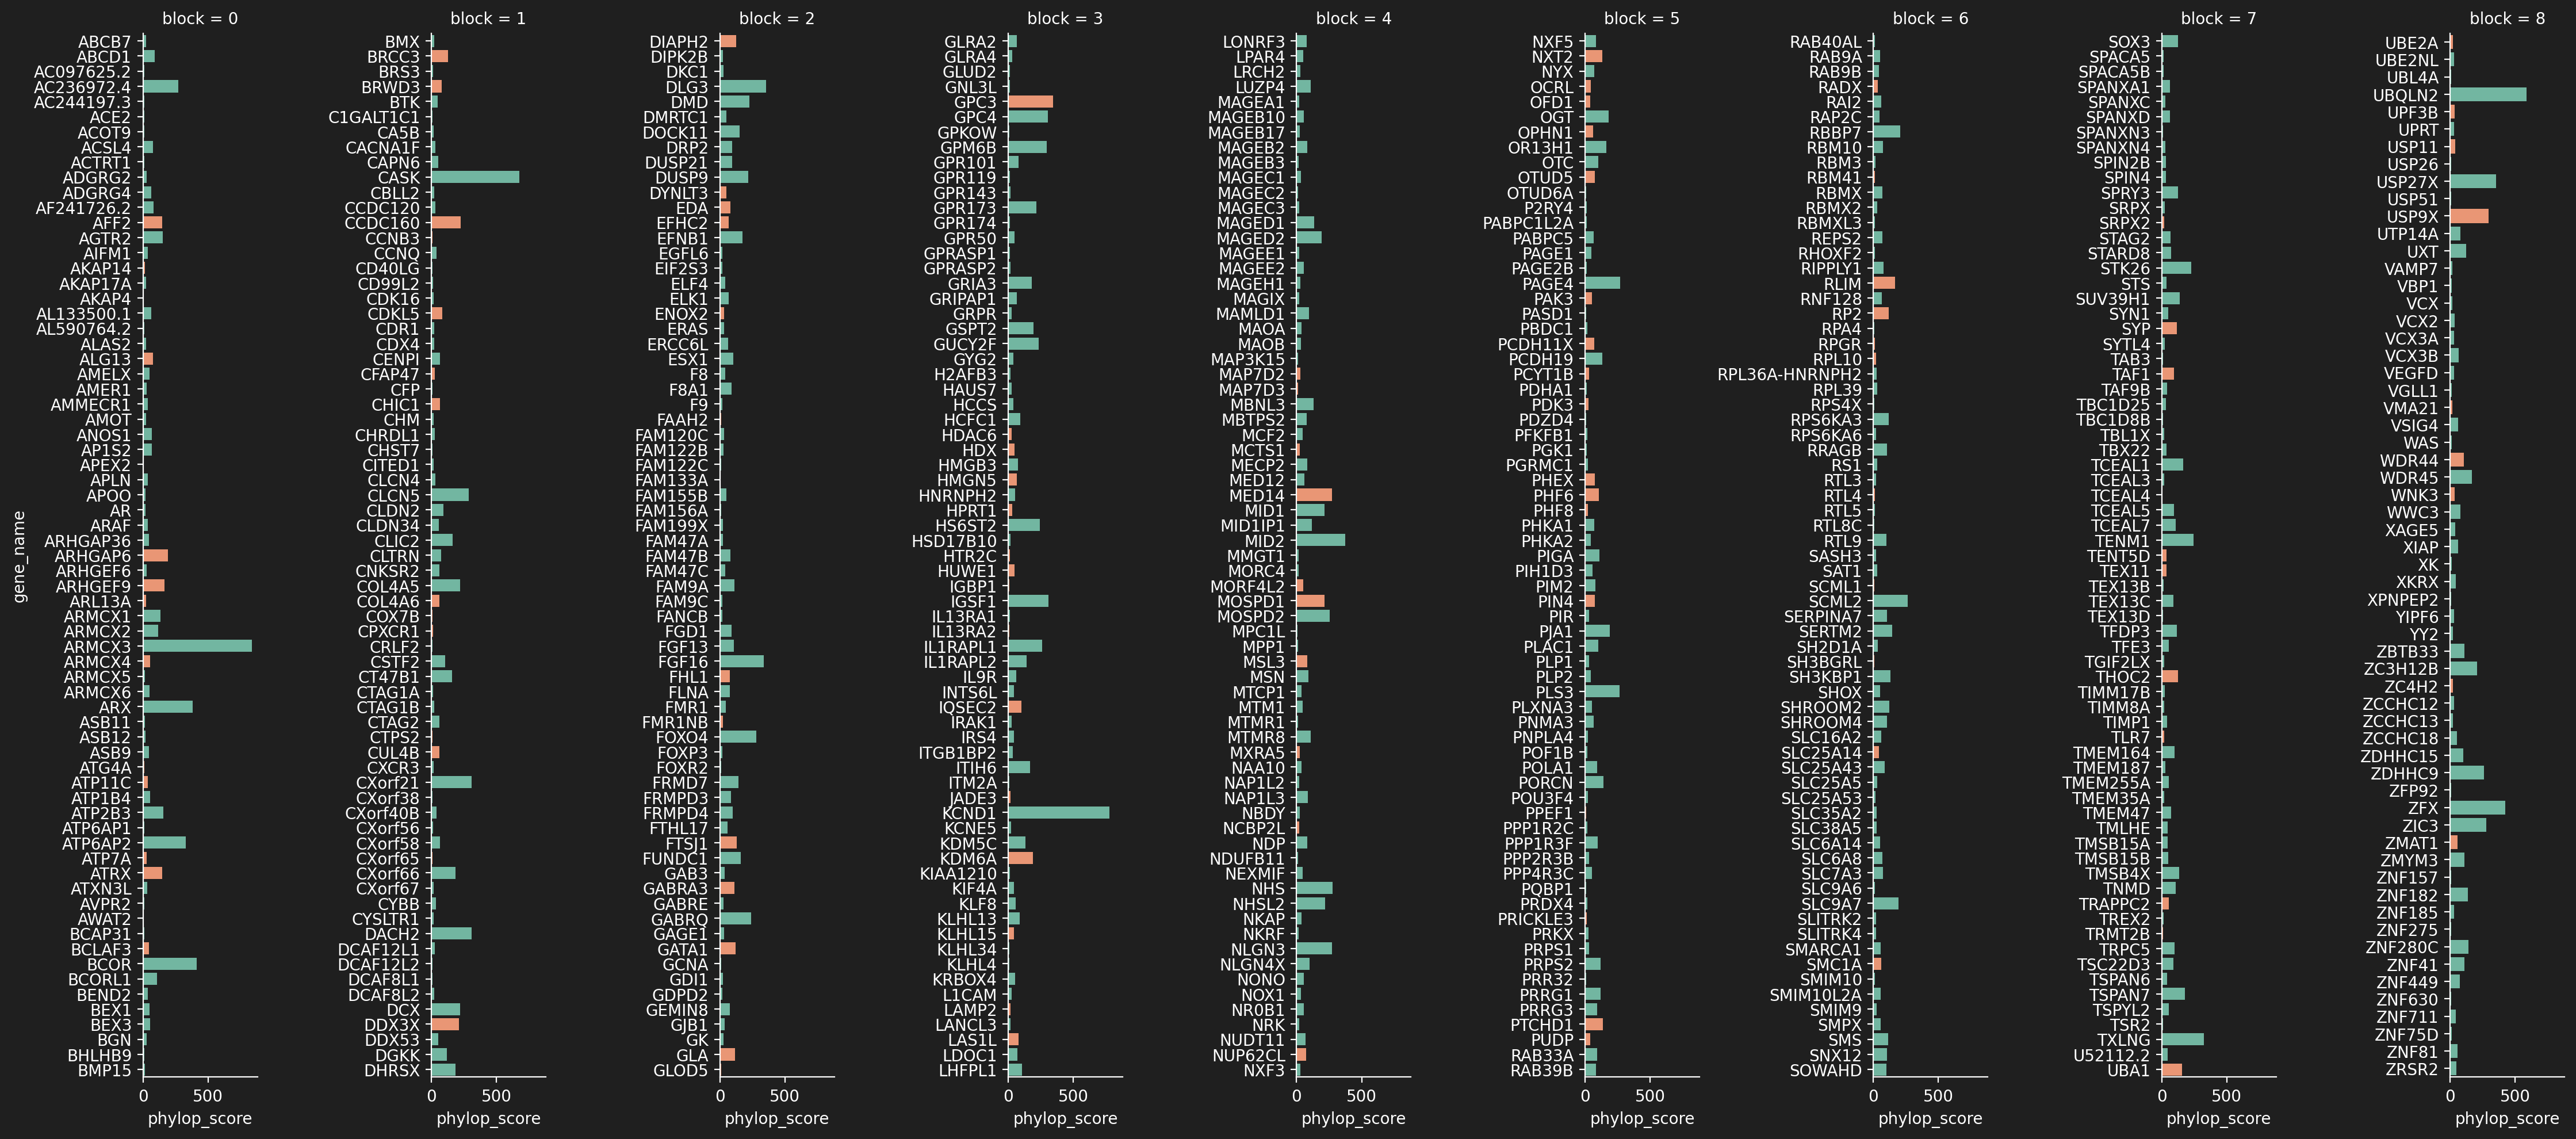

In [117]:
plot_df = (df
    .sort_values('gene_name')
    .groupby('gene_name')
    .agg({'phylop_score': 'max'}).reset_index()
)
plot_df['nDEG'] = plot_df.gene_name.isin(nDEG_genes.gene)
plot_df['cDEG'] = plot_df.gene_name.isin(cDEG_genes.gene)
plot_df.sort_values('gene_name', inplace=True)
plot_df = plot_df.merge(genes_df, left_on='gene_name', right_on='gene', how='left', validate='many_to_one', suffixes=('', '_y'))

g = sns.FacetGrid(plot_df, col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map_dataframe(barplot_facet_with_hue, 'phylop_score', 'gene_name', 'nDEG')
plt.tight_layout()
# g = sns.FacetGrid(plot_df, col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
# g.map(sns.barplot, 'phylop_score', 'gene_name')
# for ax in g.axes.flat:
#     ax.set_xlim(0, 100)
# plt.tight_layout()

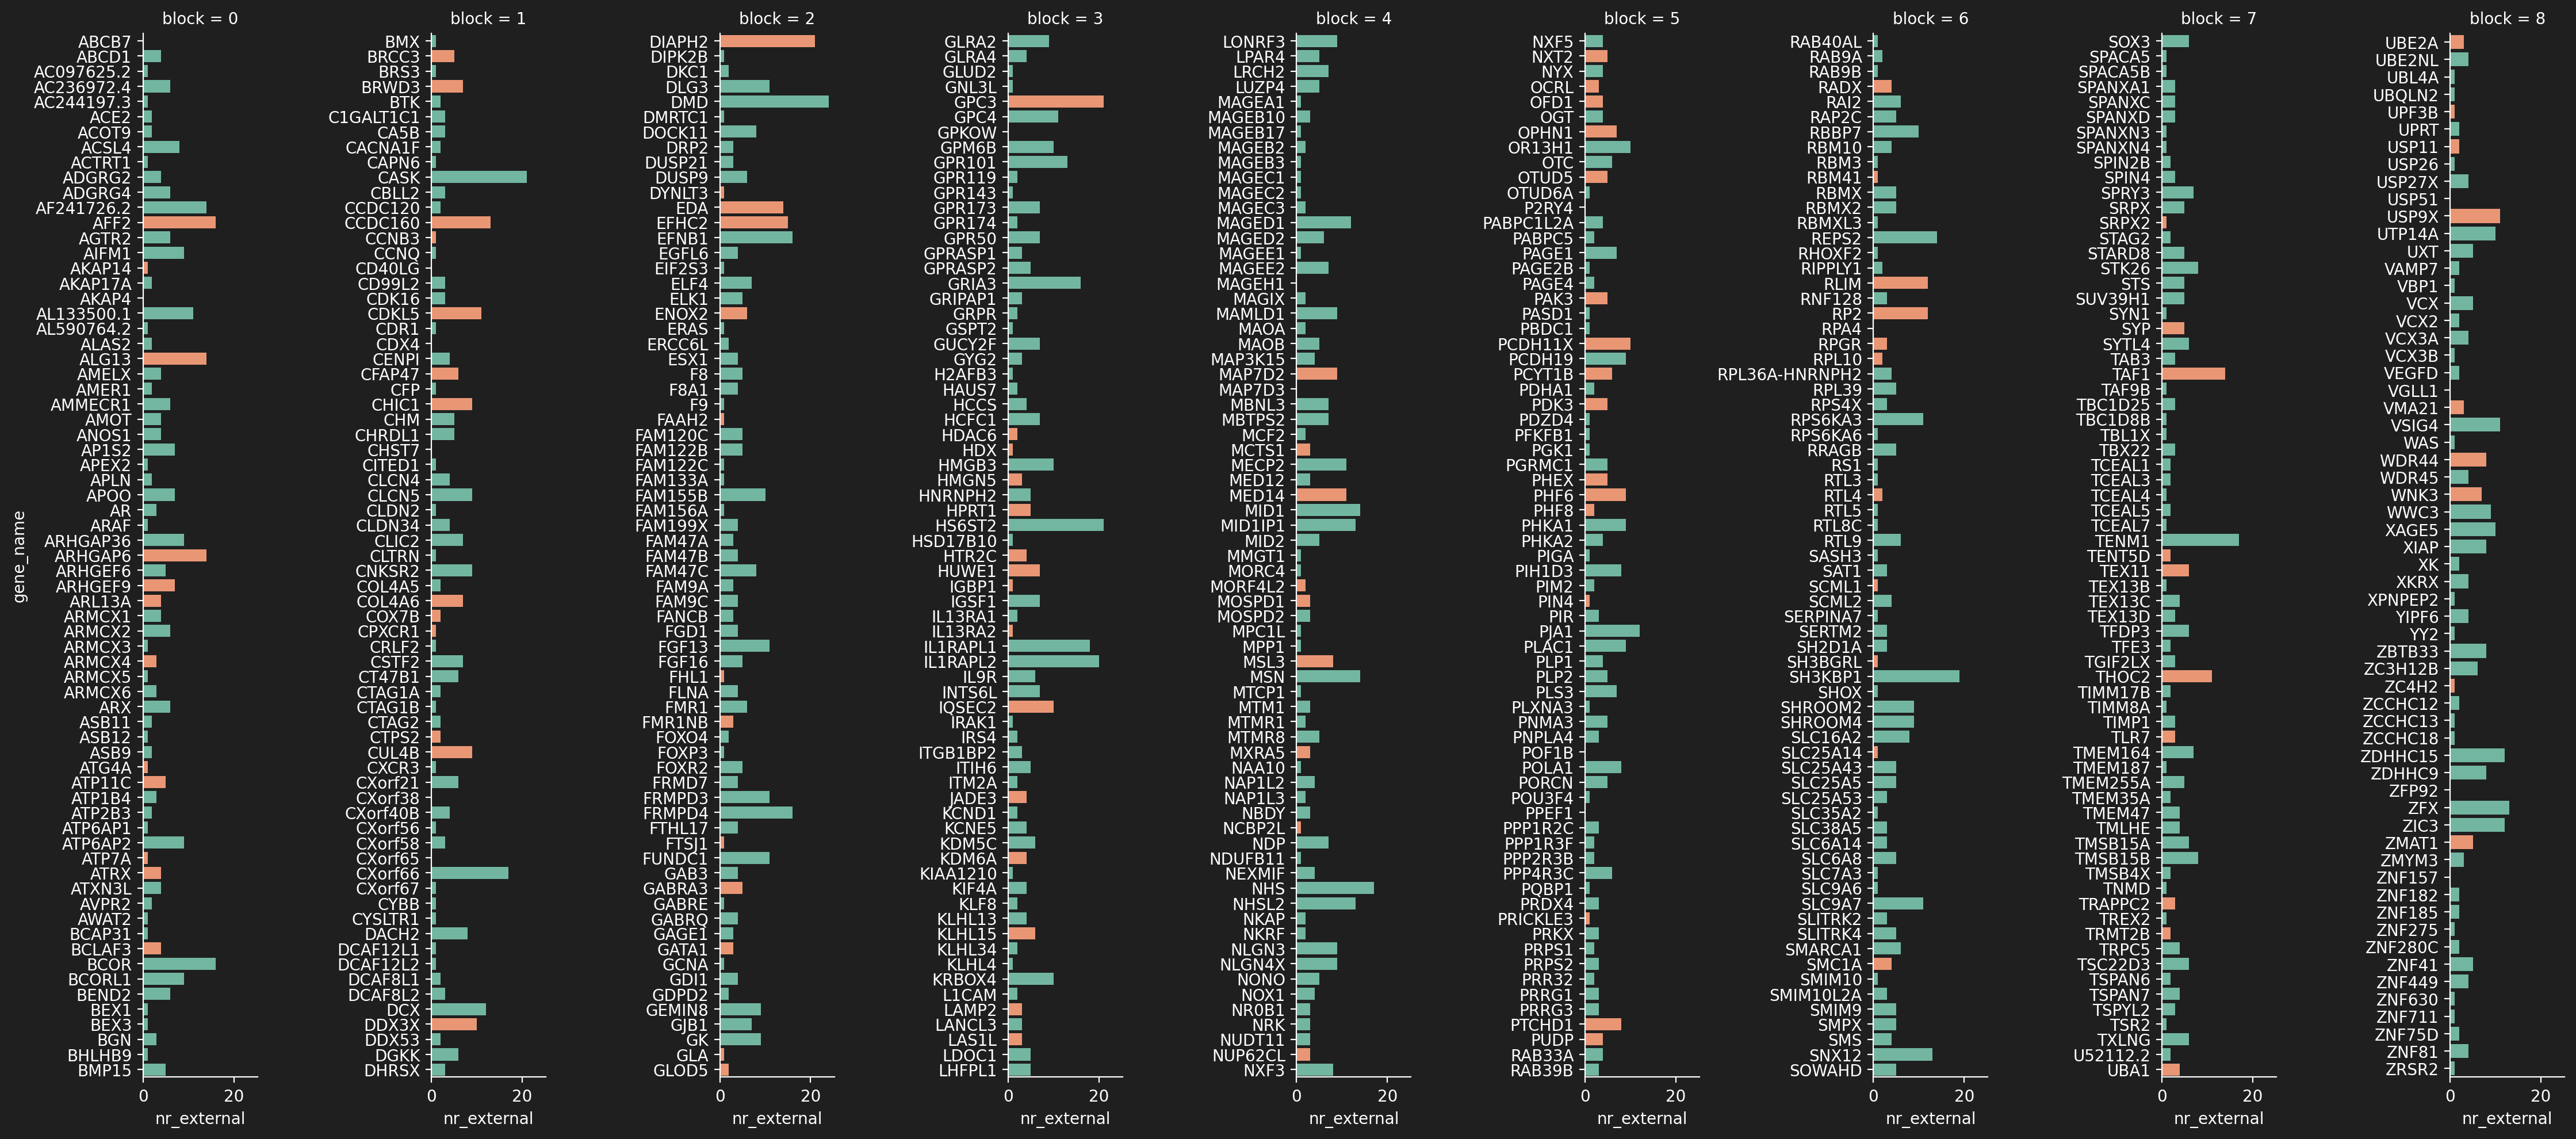

In [118]:
gr = df.groupby('gene_name')
plot_df = gr.lineage_name.agg(lambda sr: sum([len(x.split()) == 2 for x in sr.unique()])).to_frame('nr_external').reset_index()
plot_df['nDEG'] = plot_df.gene_name.isin(nDEG_genes.gene)
plot_df['cDEG'] = plot_df.gene_name.isin(cDEG_genes.gene)
plot_df.sort_values('gene_name', inplace=True)
plot_df = plot_df.merge(genes_df, left_on='gene_name', right_on='gene', how='left', validate='many_to_one', suffixes=('', '_y'))

g = sns.FacetGrid(plot_df, col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map_dataframe(barplot_facet_with_hue, 'nr_external', 'gene_name', 'nDEG')
plt.tight_layout()
# g = sns.FacetGrid(plot_df, col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
# g.map(sns.barplot, 'nr_external', 'gene_name')
# # for ax in g.axes.flat:
# #     ax.set_xlim(0, 30)
# plt.tight_layout()

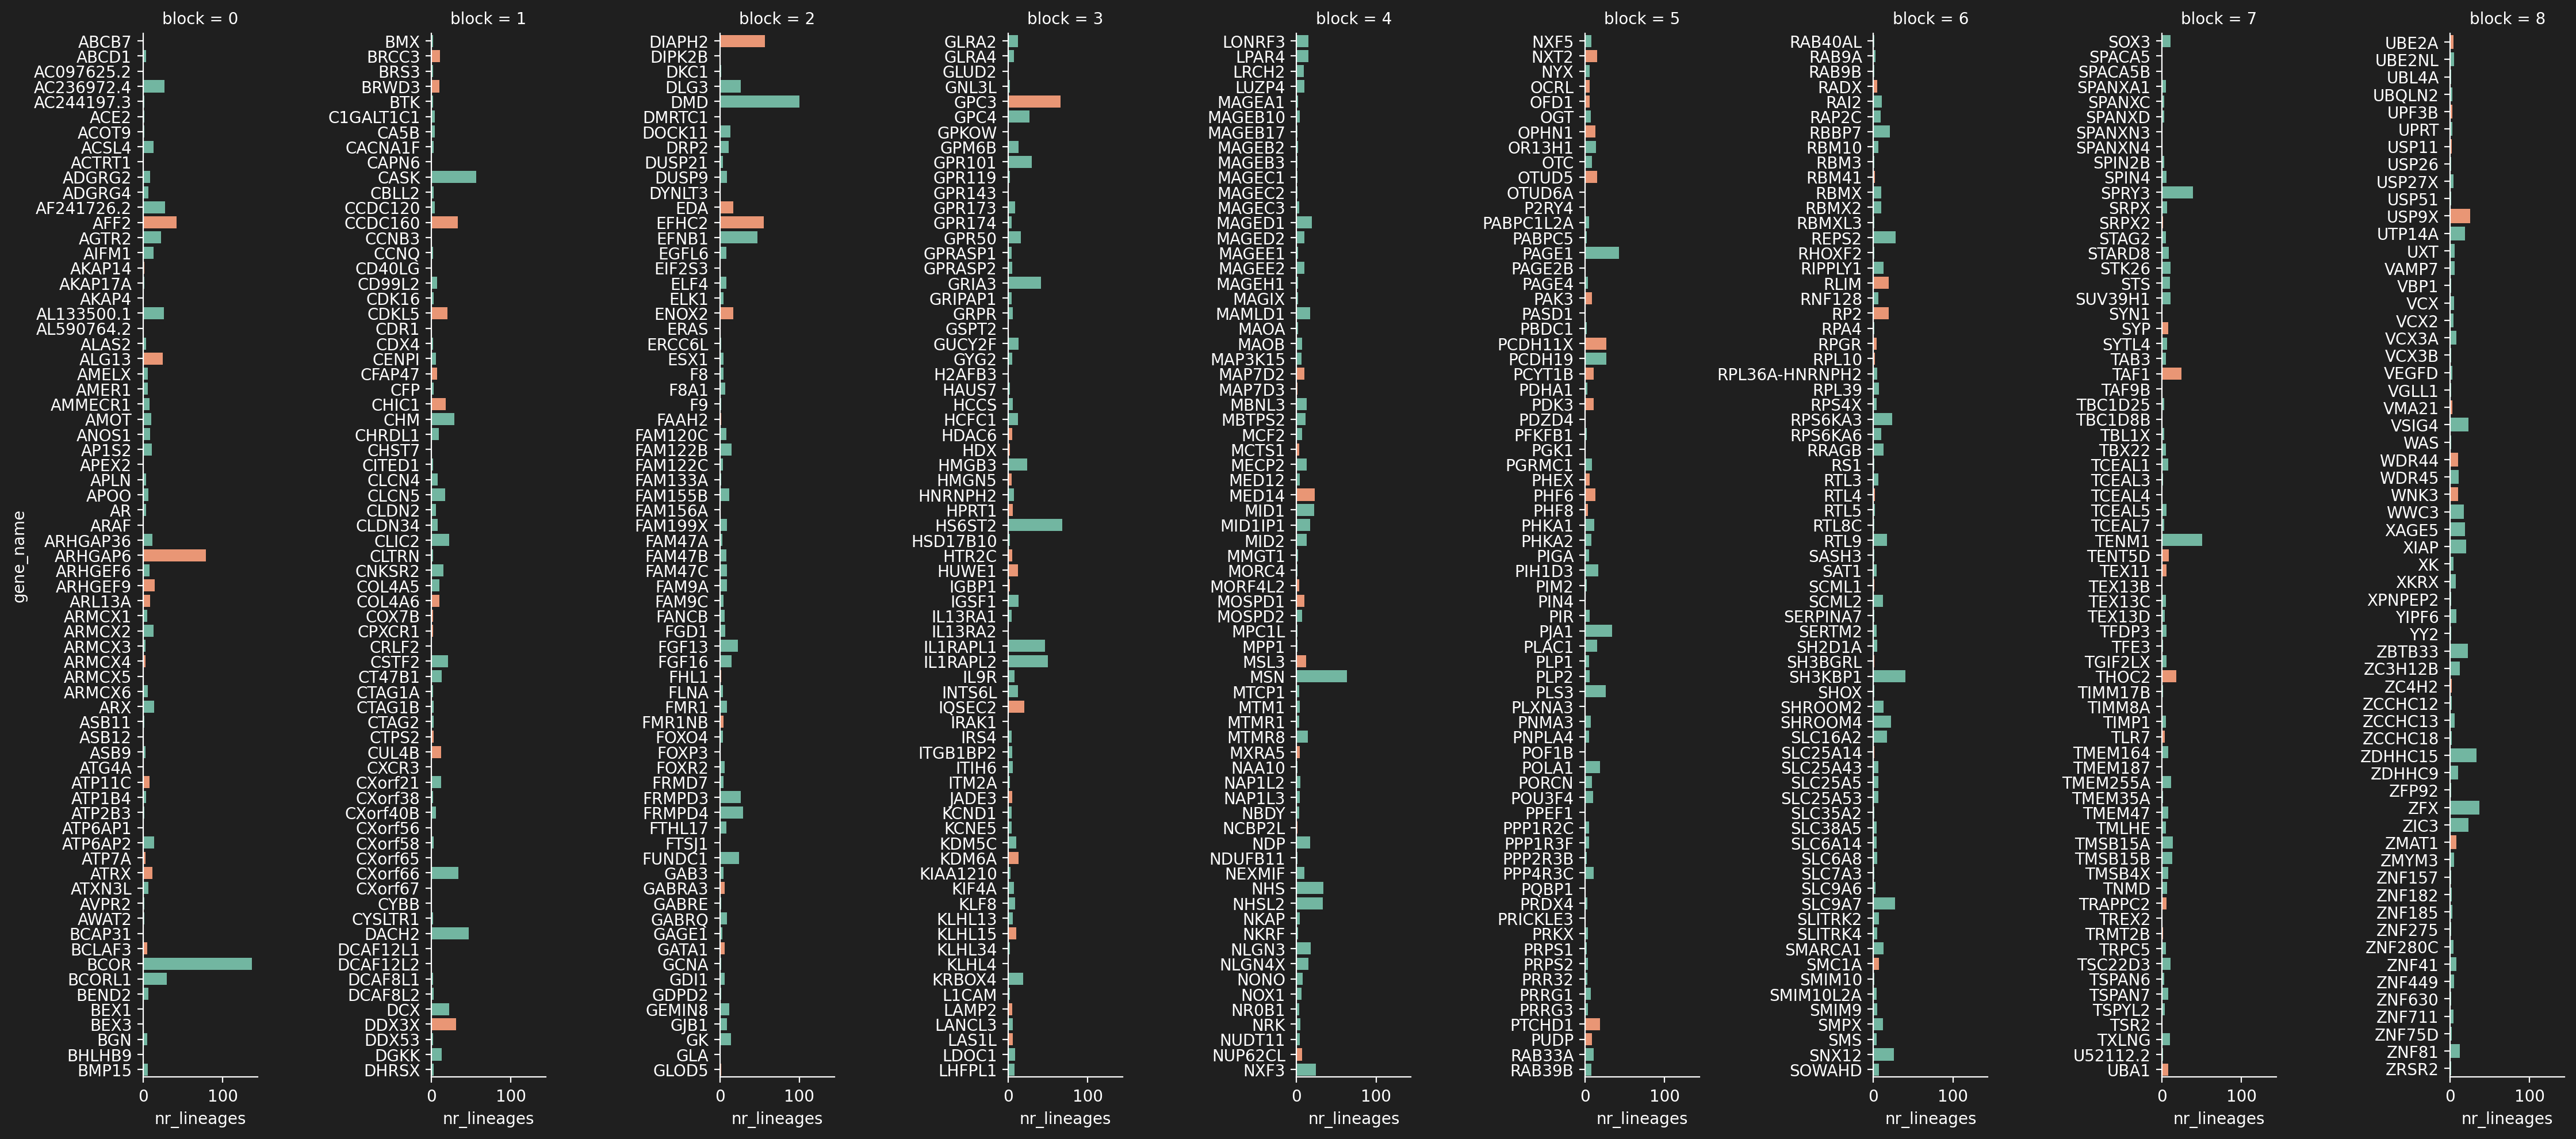

In [119]:
gr = df.groupby('gene_name', observed=True)
plot_df = gr.lineage_name.count().to_frame('nr_lineages').reset_index()
plot_df['nDEG'] = plot_df.gene_name.isin(nDEG_genes.gene)
plot_df['cDEG'] = plot_df.gene_name.isin(cDEG_genes.gene)
plot_df.sort_values('gene_name', inplace=True)
plot_df = plot_df.merge(genes_df, left_on='gene_name', right_on='gene', how='left', validate='many_to_one', suffixes=('', '_y'))

g = sns.FacetGrid(plot_df, col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map_dataframe(barplot_facet_with_hue, 'nr_lineages', 'gene_name', 'nDEG')
plt.tight_layout()
# g = sns.FacetGrid(plot_df, col='block', hue='nDEG', height=10, aspect=0.25, sharey=False, col_wrap=9)
# g.map(sns.barplot, 'nr_lineages', 'gene_name')
# # for ax in g.axes.flat:
# #     ax.set_xlim(0, 100)
# plt.tight_layout()

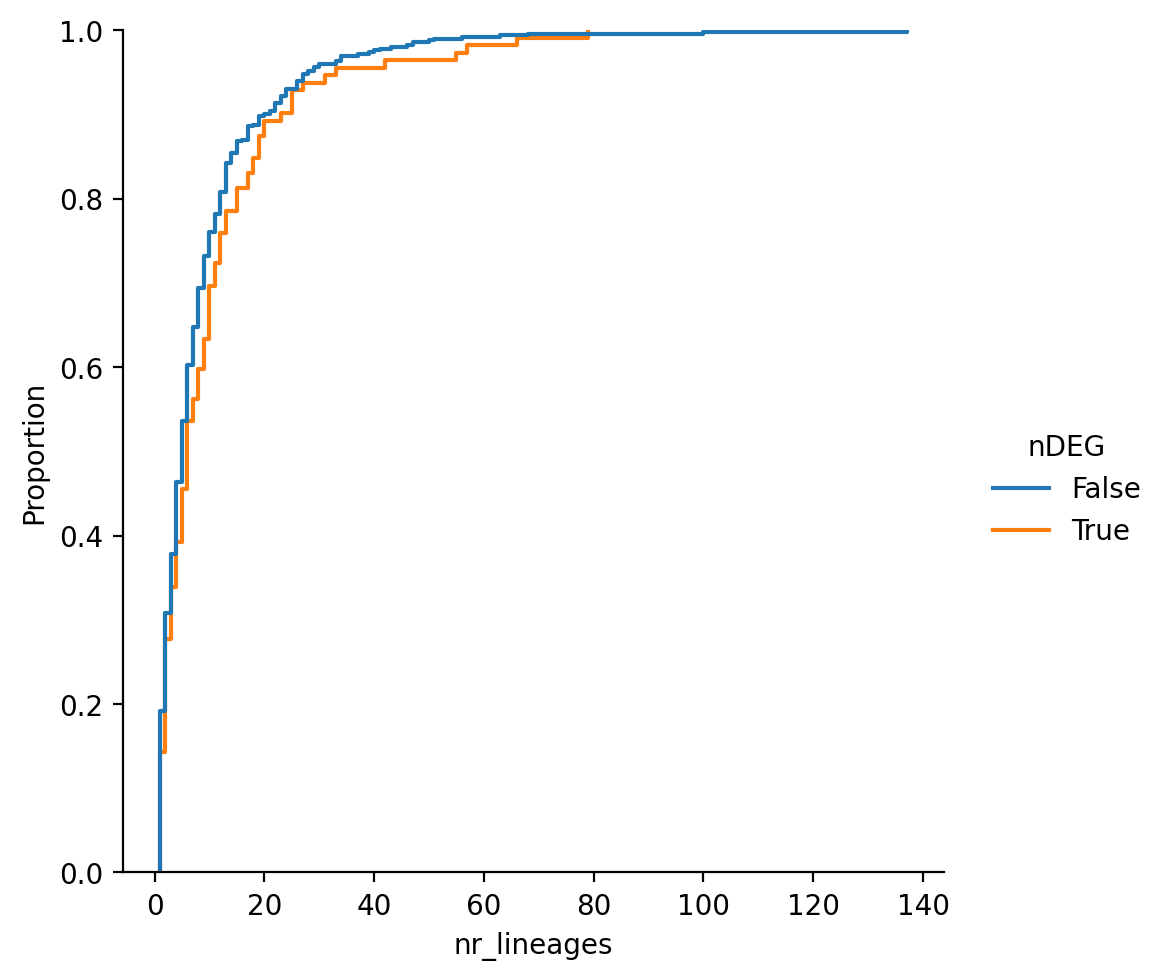

In [152]:
sns.displot(plot_df, hue='nDEG', x='nr_lineages', kind='ecdf' )

<Axes: xlabel='nr_lineages', ylabel='gene_name'>

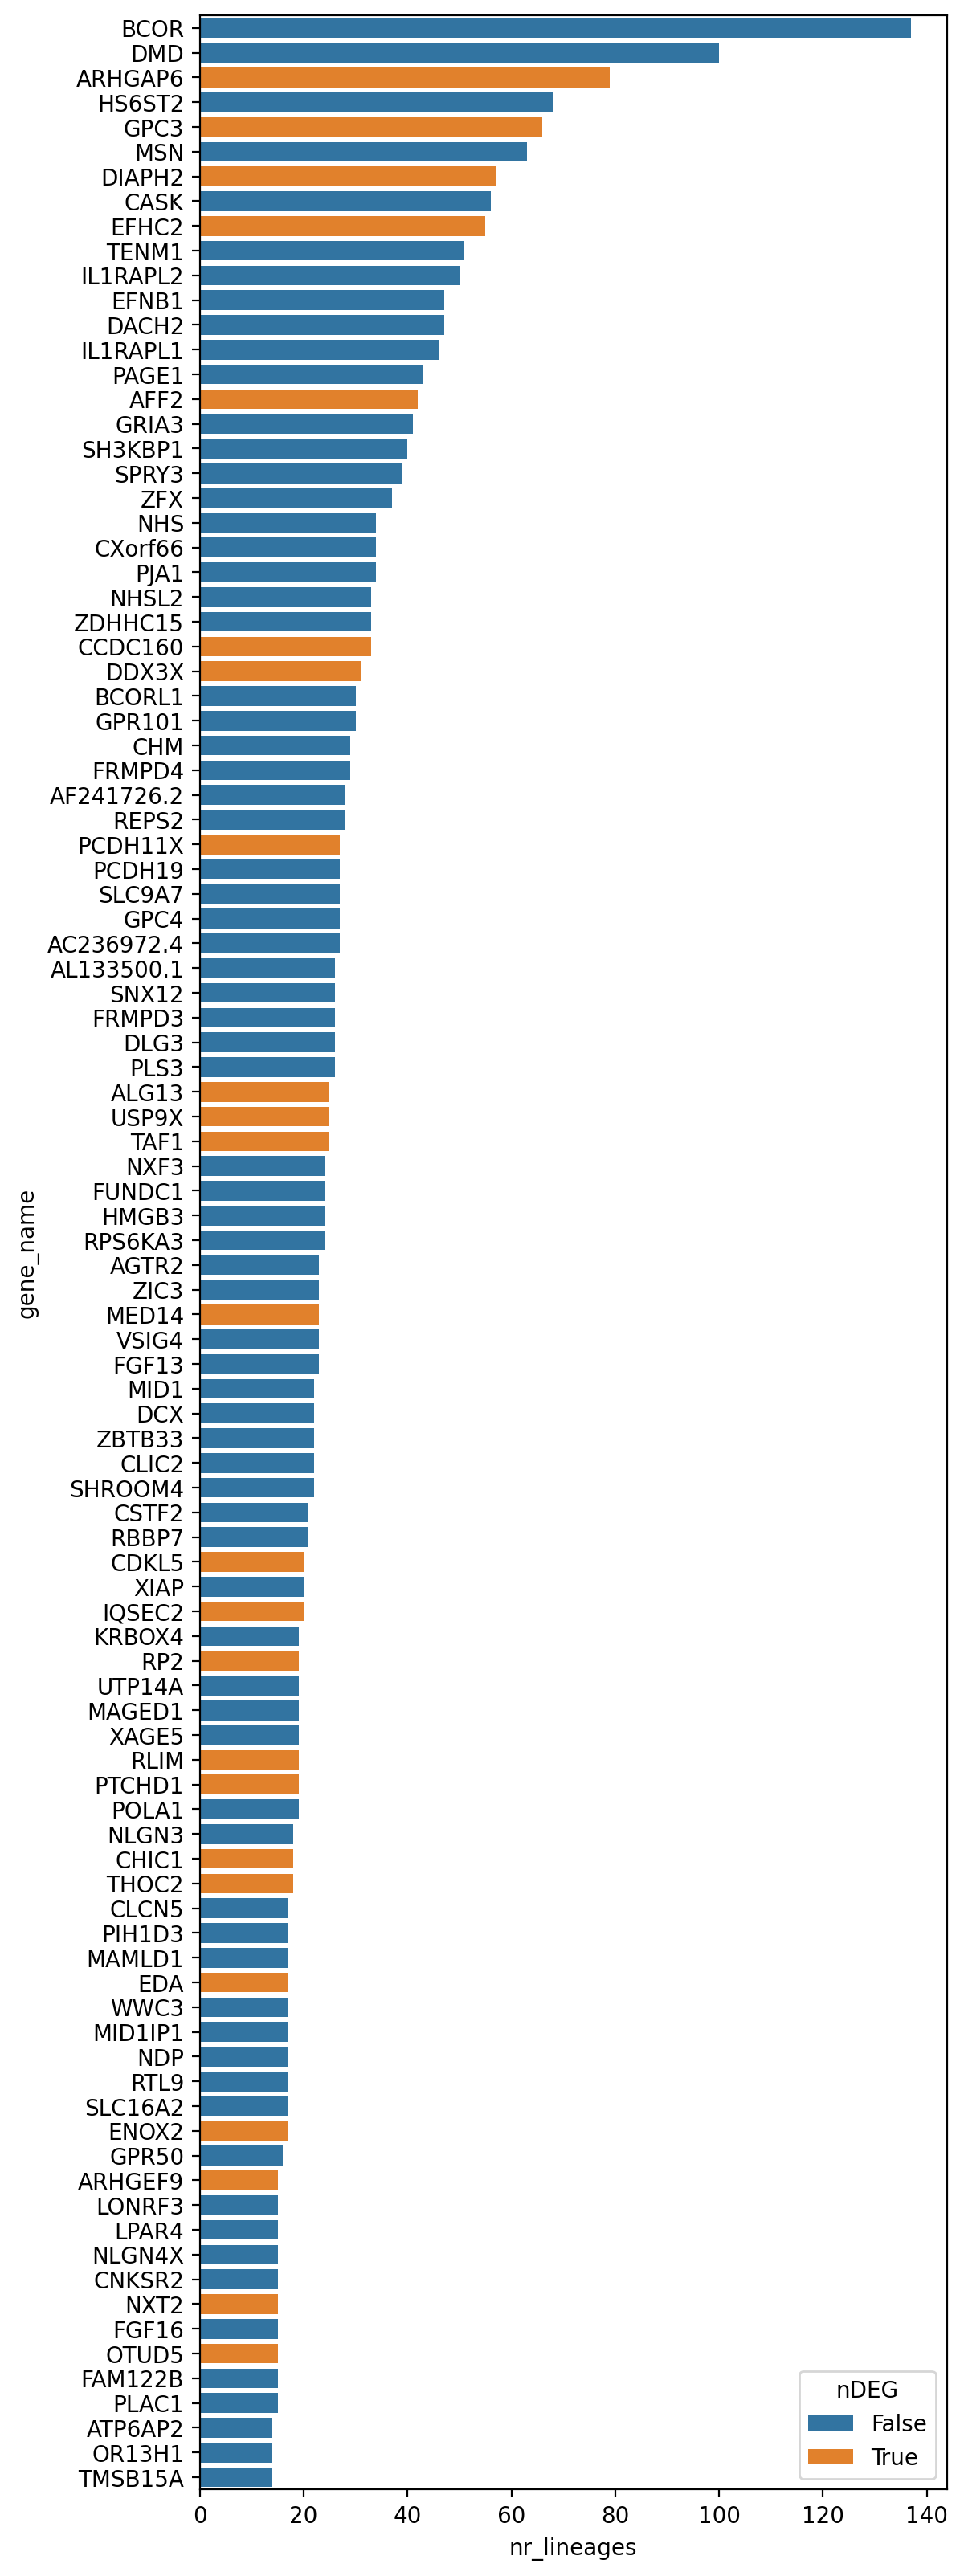

In [148]:
plt.figure(figsize=(6, 20))
sns.barplot(plot_df.sort_values('nr_lineages', ascending=False).iloc[:100], x='nr_lineages', y='gene_name', hue='nDEG')
#sns.barplot(plot_df, x='nr_lineages', y='gene_name', hue='nDEG')

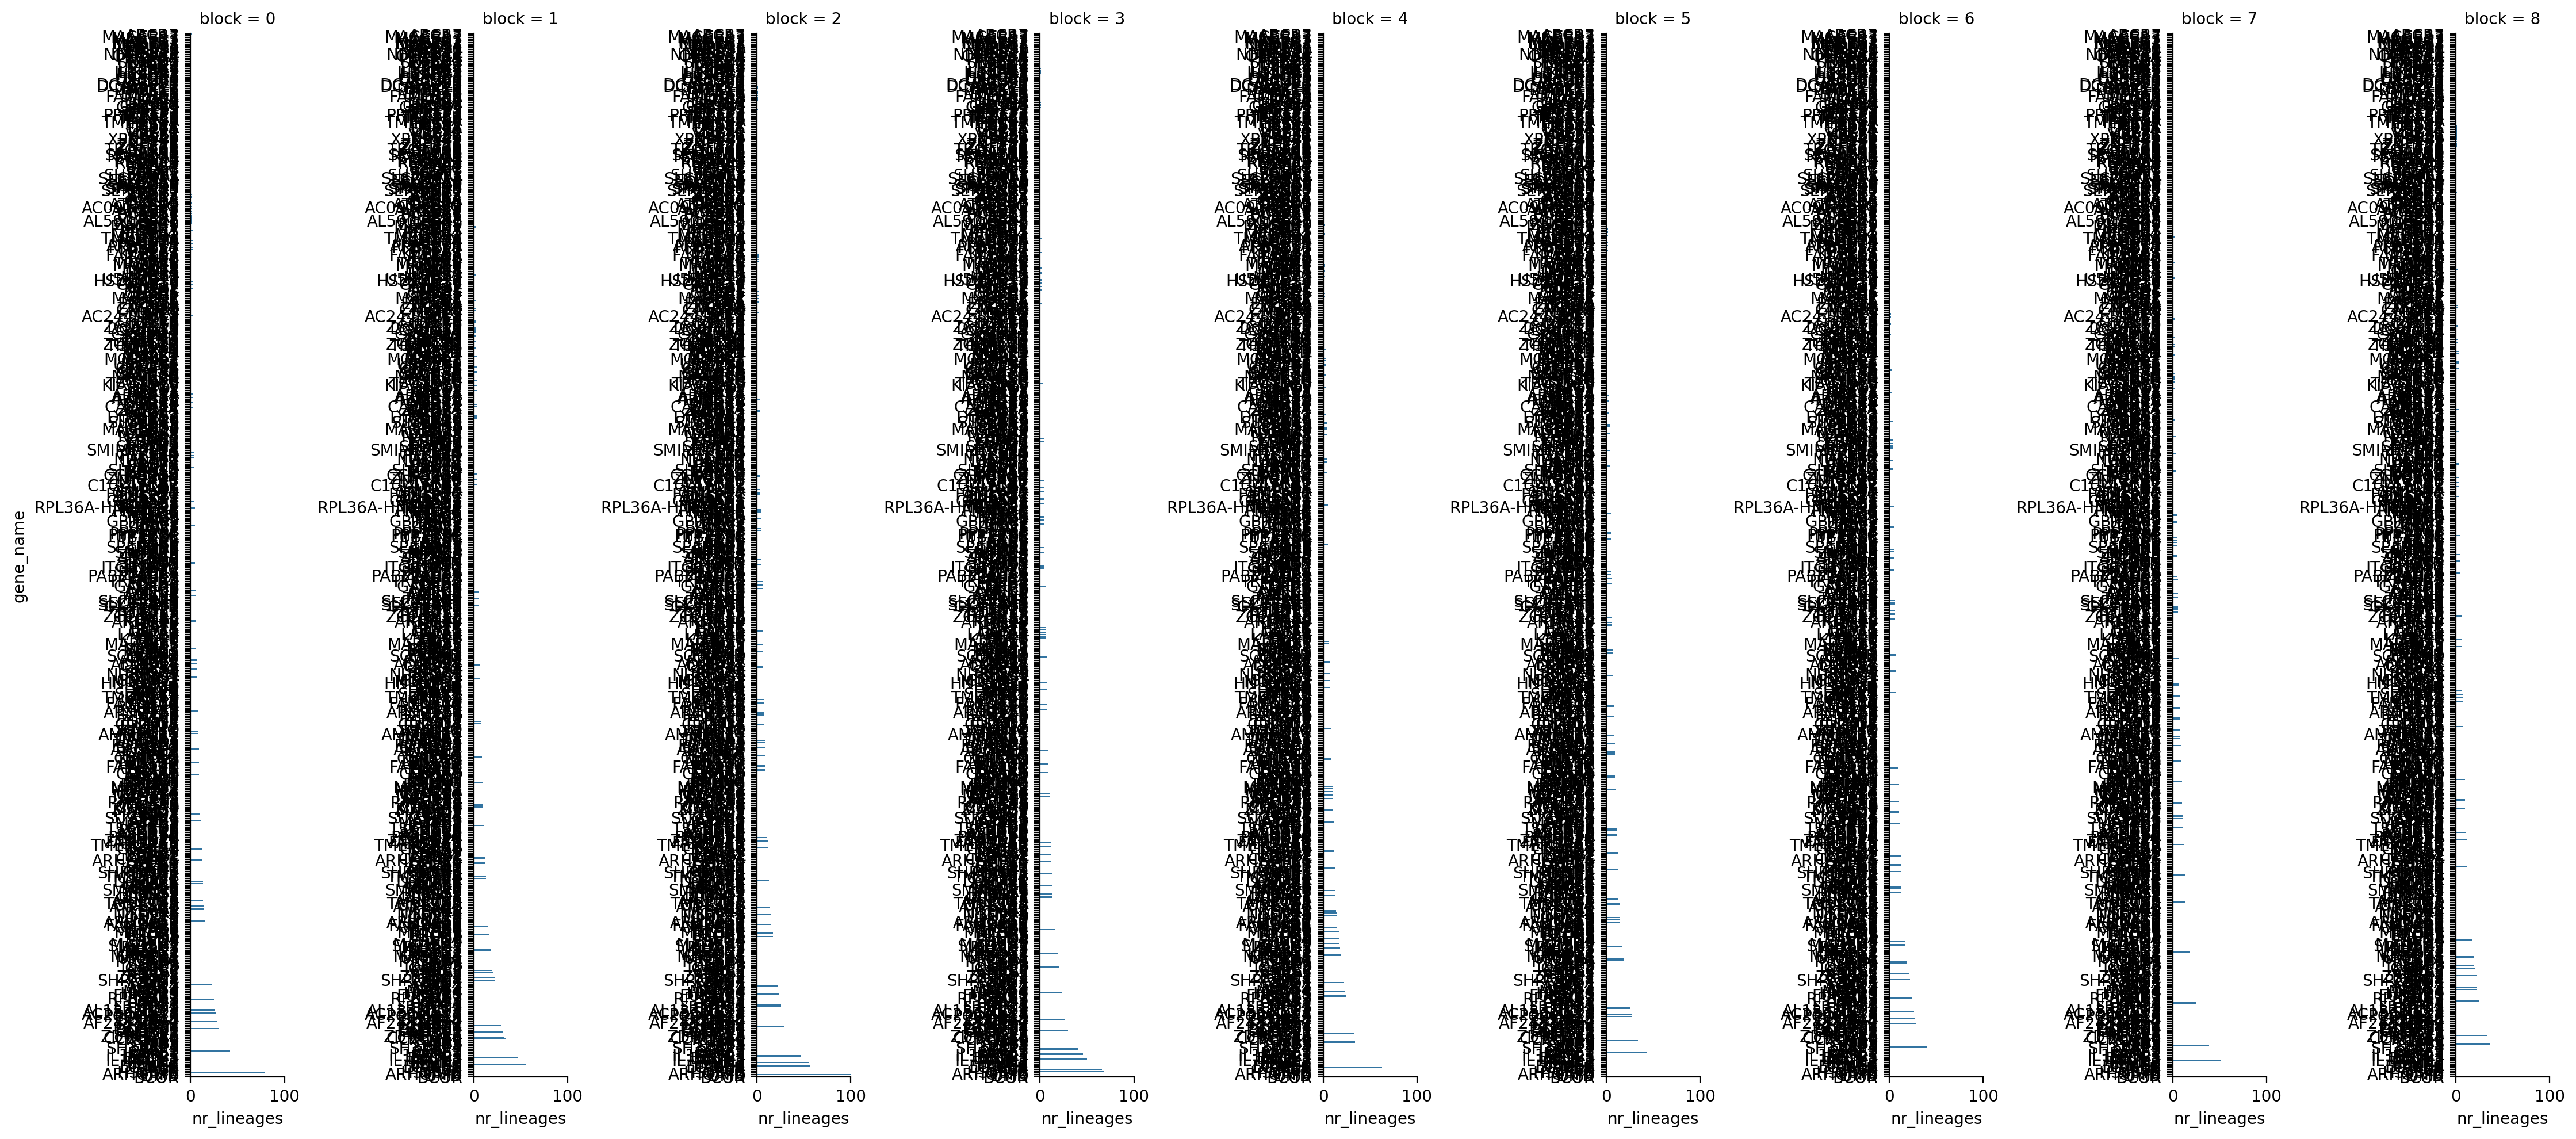

In [132]:
plot_df['gene_name'] = pd.Categorical(plot_df.gene_name, categories=plot_df.sort_values('nr_lineages').gene_name, ordered=True)

g = sns.FacetGrid(plot_df.sort_values('nr_lineages'), col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map(sns.barplot, 'nr_lineages', 'gene_name')
for ax in g.axes.flat:
    ax.set_xlim(0, 100)
plt.tight_layout()

In [ ]:

g = sns.FacetGrid(plot_df.sort_values('nr_lineages'), col='block', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map(sns.barplot, 'nr_lineages', 'gene_name')
for ax in g.axes.flat:
    ax.set_xlim(0, 100)
plt.tight_layout()

In [ ]:

plot_df = (df
.loc[(df.gene_name != 'NONE') & (df.chrom == 'chrX')]
.sort_values('gene_name')
.assign(block=lambda x: x.index // (1 + x.index.size // 9))
)
plot_df['nDEG'] = df.gene_name.isin(nDEG_genes.gene)
plot_df['cDEG'] = df.gene_name.isin(cDEG_genes.gene)

g = sns.FacetGrid(plot_df, col='block', hue='nDEG', height=10, aspect=0.25, sharey=False, col_wrap=9)
g.map(sns.pointplot, 'phylop_score', 'gene_name', join=False)
for ax in g.axes.flat:
    ax.set_xlim(0, 100)
plt.tight_layout()